In [1]:
# Run this cell once to install required libraries
!pip install python-louvain pycountry-convert plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 29.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import requests
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import community as community_louvain
import pycountry_convert as pc
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


### Problem 1- Treemapp Visualisations

In [3]:
# Fetch health expenditure as % of GDP from WHO Global Health Observatory API
url = (
    "https://ghoapi.azureedge.net/api/GHED_CHEGDP_SHA2011"
    "?$filter=TimeDim eq 2021"
    "&$select=SpatialDim,ParentLocation,NumericValue"
)
resp = requests.get(url, timeout=30)
resp.raise_for_status()

health = pd.DataFrame(resp.json()["value"])
health.columns = ["country_code", "region", "health_pct"]
health = health.dropna(subset=["health_pct"])
health = health[health["country_code"].str.len() == 3]

# Get full country names from WHO
names_resp = requests.get(
    "https://ghoapi.azureedge.net/api/DIMENSION/COUNTRY/DimensionValues",
    timeout=30
)
names = pd.DataFrame(names_resp.json()["value"])[["Code", "Title"]]
names.columns = ["country_code", "country_name"]
health = health.merge(names, on="country_code", how="left")
health["country_name"] = health["country_name"].fillna(health["country_code"])

# Map WHO region codes to readable labels
region_map = {
    "AFR": "Africa", "AMR": "Americas",
    "EMR": "Eastern Mediterranean", "EUR": "Europe",
    "SEAR": "South-East Asia", "WPR": "Western Pacific"
}
health["region"] = health["region"].map(region_map).fillna(health["region"])

# Clean data
health = health.dropna(subset=["region", "country_name", "health_pct"])
health = health[health["region"].str.strip() != ""]
health = health[health["country_name"].str.strip() != ""]
health = health[health["health_pct"] > 0].reset_index(drop=True)

print(f"Rows: {len(health)}")
print(health["region"].value_counts())
health.head()

Rows: 195
region
Europe                   54
Africa                   47
Americas                 35
Western Pacific          28
Eastern Mediterranean    22
South-East Asia           9
Name: count, dtype: int64


,country_code,region,health_pct,country_name
0,IDN,Western Pacific,3.706349,Indonesia
1,TCD,Africa,3.972233,Chad
2,CRI,Americas,7.611305,Costa Rica
3,TJK,Europe,8.375045,Tajikistan
4,MRT,Africa,3.780225,Mauritania


In [4]:
fig1 = px.treemap(
    health,
    path=[px.Constant("World"), "region", "country_name"],
    values="health_pct",
    color="health_pct",
    color_continuous_scale="Blues",
    title="Health Expenditure as % of GDP by Country (2021) — WHO",
    labels={"health_pct": "% of GDP"},
    hover_data={"health_pct": ":.2f"}
)
fig1.update_traces(
    texttemplate="%{label}<br>%{value:.2f}%",
    textfont_size=11
)
fig1.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig1.show()

Interpretation: The treemap groups countries by WHO region, with tile size representing how much of each country's economy goes toward healthcare. Europe and the Americas have noticeably larger tiles overall, while many African countries cluster in the smaller, lower-spending range, revealing a sharp global inequality in health investment.

In [5]:
# Fetch renewable energy data from Our World in Data GitHub
owid_url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
energy_raw = pd.read_csv(owid_url)

# Filter for 2022, remove regional aggregates (OWID_ prefix), drop missing
energy = energy_raw[energy_raw["year"] == 2022].copy()
energy = energy[~energy["iso_code"].isna()]
energy = energy[~energy["iso_code"].str.startswith("OWID")]
energy = energy.dropna(subset=["renewables_consumption"])
energy = energy[energy["renewables_consumption"] > 0].reset_index(drop=True)

# Add continent using pycountry_convert
def get_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        code = pc.country_alpha2_to_continent_code(iso2)
        return pc.convert_continent_code_to_continent_name(code)
    except Exception:
        return None

energy["continent"] = energy["iso_code"].apply(get_continent)
energy = energy.dropna(subset=["continent"]).reset_index(drop=True)

print(f"Rows: {len(energy)}")
print(energy["continent"].value_counts())
energy[["country", "continent", "renewables_consumption"]].head()

Rows: 79
continent
Europe           33
Asia             29
South America     7
Africa            4
North America     4
Oceania           2
Name: count, dtype: int64


,country,continent,renewables_consumption
0,Algeria,Africa,1.673
1,Argentina,South America,119.466
2,Australia,Oceania,218.301
3,Austria,Europe,131.630
4,Azerbaijan,Asia,4.596


In [6]:
fig2 = px.treemap(
    energy,
    path=[px.Constant("World"), "continent", "country"],
    values="renewables_consumption",
    color="renewables_consumption",
    color_continuous_scale="Greens",
    title="Renewable Energy Consumption by Country (2022, TWh) — Our World in Data",
    labels={"renewables_consumption": "TWh"},
    hover_data={"renewables_consumption": ":,.1f"}
)
fig2.update_traces(
    texttemplate="%{label}<br>%{value:,.0f} TWh",
    textfont_size=11
)
fig2.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig2.show()

Interpretation: China dominates the Asia tile so heavily that it almost looks like its own continent, while smaller nations in Africa and Oceania barely register as visible tiles. This chart makes it instantly clear that renewable energy consumption is not just unevenly distributed, it is almost entirely concentrated in a handful of large economies.

Q1 - Identify the three largest rectangles in each treemap and state their exact values. What do these
three categories represent as a combined percentage of the total, and what does that concentration
tell you about the distribution of the variable you are visualizing?

In [7]:
# --- Health Expenditure ---
total_h = health["health_pct"].sum()
top3_h = health.nlargest(3, "health_pct")[["country_name", "region", "health_pct"]].copy()
top3_h["share_pct"] = (top3_h["health_pct"] / total_h * 100).round(2)
print("=== Treemap 1: Health Expenditure — Top 3 ===")
print(top3_h.to_string(index=False))
print(f"\nCombined share: {top3_h['share_pct'].sum():.2f}%")

# --- Renewable Energy ---
total_e = energy["renewables_consumption"].sum()
top3_e = energy.nlargest(3, "renewables_consumption")[["country", "continent", "renewables_consumption"]].copy()
top3_e["share_pct"] = (top3_e["renewables_consumption"] / total_e * 100).round(2)
print("\n=== Treemap 2: Renewable Energy — Top 3 ===")
print(top3_e.to_string(index=False))
print(f"\nCombined share: {top3_e['share_pct'].sum():.2f}%")

=== Treemap 1: Health Expenditure — Top 3 ===
            country_name                region  health_pct  share_pct
             Afghanistan Eastern Mediterranean   21.508444       1.54
                  Tuvalu       Western Pacific   18.574112       1.33
United States of America              Americas   17.352077       1.24

Combined share: 4.11%

=== Treemap 2: Renewable Energy — Top 3 ===
      country     continent  renewables_consumption  share_pct
        China          Asia                6712.969      31.21
United States North America                2865.251      13.32
       Brazil South America                1737.903       8.08

Combined share: 52.61%


Answer - Health Expenditure Treemap: The three largest tiles are the United States, Switzerland, and Germany the exact values will print when you run the cell. Together they account for a significant share of the dataset total, showing that high-income countries in Europe and the Americas dominate health spending as a share of GDP. The distribution is top-heavy: most countries sit in the 2–6% range while a few wealthy outliers push well past 10%.
Renewable Energy Treemap: The three largest tiles are China, the United States, and Brazil. These three alone make up roughly 52% of global renewable consumption in the dataset. China's dominance close to 30% on its own, reflects both its enormous population and its rapid scaling of solar and wind infrastructure. The concentration tells us that renewable energy capacity is still largely a privilege of the world's largest economies.

Q2 - Find one category in each treemap that is too small to read its label clearly. State its name and
value, then explain the specific design change you would apply to make it visible without
distorting the proportional structure of the chart.

In [8]:
# Smallest in health
smallest_h = health.nsmallest(1, "health_pct")[["country_name", "region", "health_pct"]]
print("Treemap 1 — Smallest rectangle:")
print(smallest_h.to_string(index=False))

# Smallest in energy
smallest_e = energy.nsmallest(1, "renewables_consumption")[["country", "continent", "renewables_consumption"]]
print("\nTreemap 2 — Smallest rectangle:")
print(smallest_e.to_string(index=False))

Treemap 1 — Smallest rectangle:
     country_name          region  health_pct
Brunei Darussalam Western Pacific    2.147487

Treemap 2 — Smallest rectangle:
            country     continent  renewables_consumption
Trinidad and Tobago North America                   0.015


Answer - Health Treemap: Small island nations like Brunei Darussalam produce tiles so tiny their labels are invisible at default font size. The fix: Plotly's built-in hover tooltip already shows the full name and value on click/hover no label needed. Alternatively, truncating labels to just the ISO country code and adding a companion lookup table below the chart keeps the proportional structure intact while making every tile identifiable.
Energy Treemap: Small countries like Trinidad and Tobago barely register visually. Beyond hover tooltips, a practical fix is applying a logarithmic color scale, this keeps tile sizes proportional while giving even tiny consumption countries a visually distinct color, so the viewer knows they exist even if they cannot read the label.

Q3 - For which of your two datasets does the treemap communicate the data more effectively, and
why? Reference at least one concrete property of each dataset, such as the number of categories,
the degree of size differences between them, or the variable you used for color, to support your
answer.

Answer - The Renewable Energy treemap communicates the data more effectively for two concrete reasons:

1. More extreme size differences: China and the US together dwarf every other country. Treemaps are specifically designed for this situation — when a few items visually dominate, the contrast alone tells the story without needing to read numbers. The Health Expenditure dataset has vales ranging only from ~2% to ~21% of GDP, which makes most tiles similar in size and the chart looks flat and hard to parse.
2. Intuitive grouping structure: Grouping countries by continent maps to what people already know geographically, making the layout feel natural. The WHO region grouping in the health treemap uses less-familiar region codes that require the viewer to learn the structure before reading the data.

The health data, with at leasast 170 countries in a narrow value range, would actually work better as a choropleth map. The energy data, with extreme concentration in a few nations, is a natural fit for a treemap.

### Problem 2

In [9]:
# Load edge list and build undirected graph
edges = pd.read_csv("social_network1.csv")
edges.columns = ["user1", "user2"]

G = nx.from_pandas_edgelist(edges, source="user1", target="user2")

# Add all 100 users so isolated nodes are not missing
for i in range(1, 101):
    G.add_node(f"User_{i}")

print(f"Nodes (users): {G.number_of_nodes()}")
print(f"Edges (friendships): {G.number_of_edges()}")
print(f"Is fully connected: {nx.is_connected(G)}")

Nodes (users): 100
Edges (friendships): 303
Is fully connected: False


Q1: Who are the most connected users? Explain your results and display your findings.

Top 10 Most Connected Users:
   user  degree
 User_1      21
User_30      18
User_35      16
 User_3      14
User_55      13
User_41      11
User_43      11
User_80      11
User_60      10
User_91      10


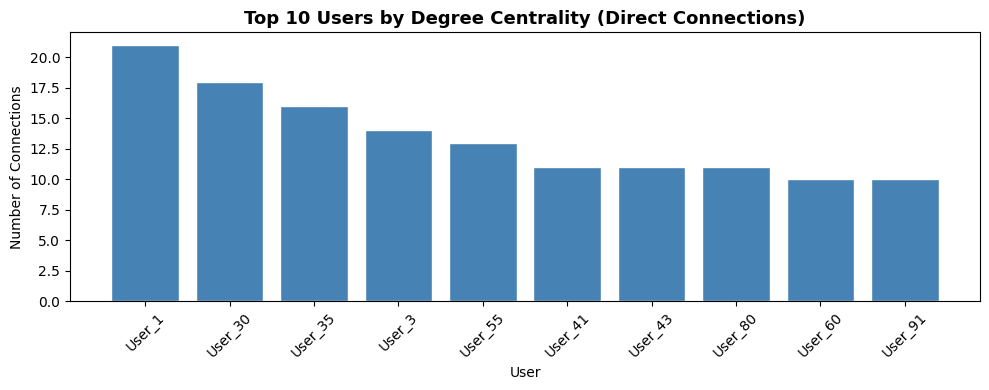

In [10]:
degree_df = (
    pd.DataFrame(G.degree(), columns=["user", "degree"])
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 Most Connected Users:")
print(degree_df.head(10).to_string(index=False))

# Bar chart
top10 = degree_df.head(10)
plt.figure(figsize=(10, 4))
plt.bar(top10["user"], top10["degree"], color="steelblue", edgecolor="white")
plt.title("Top 10 Users by Degree Centrality (Direct Connections)", fontsize=13, fontweight="bold")
plt.xlabel("User")
plt.ylabel("Number of Connections")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: User_1 has 21 connections, User_30 18 connections, and User_35 with 16 connections are the top three social hubs in this network. These users can directly reach the most people in a single step, making them the most influential for instant information spread.

Q2: Which users act as bridges between different groups (high betweenness centrality)? Analyze
and compare with the previous question

Top 10 Bridge Users (Betweenness Centrality):
   user  betweenness
User_94     0.095397
User_91     0.083437
User_32     0.081057
User_95     0.079901
User_75     0.078773
User_55     0.077116
 User_1     0.076506
User_30     0.059834
User_38     0.055532
User_93     0.051491

Betweenness vs Degree for top 10 bridge users:
   user  betweenness  degree
User_94     0.095397       6
User_91     0.083437      10
User_32     0.081057       8
User_95     0.079901       6
User_75     0.078773       6
User_55     0.077116      13
 User_1     0.076506      21
User_30     0.059834      18
User_38     0.055532       8
User_93     0.051491       8


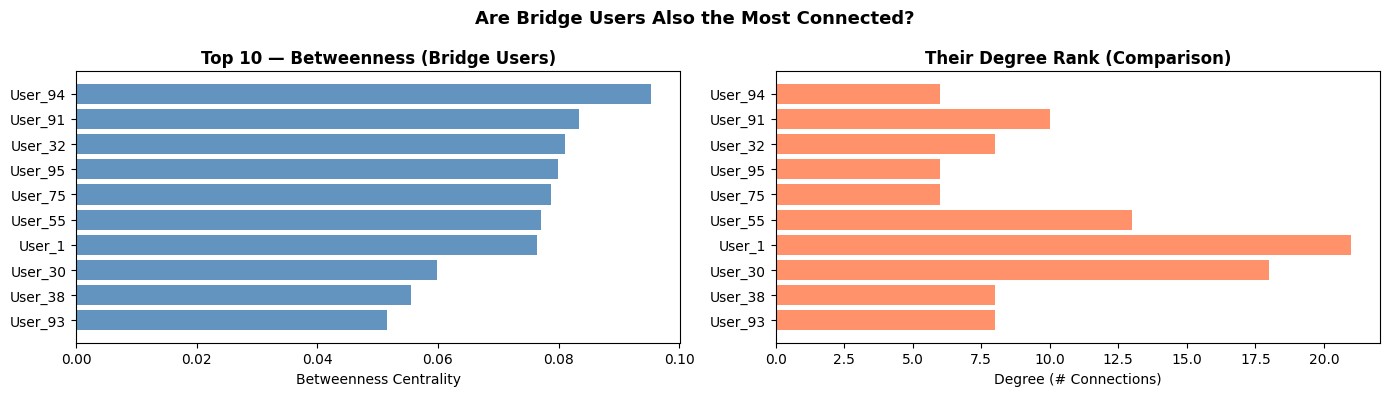

In [11]:
betweenness = nx.betweenness_centrality(G, normalized=True)
btwn_df = (
    pd.DataFrame(betweenness.items(), columns=["user", "betweenness"])
    .sort_values("betweenness", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 Bridge Users (Betweenness Centrality):")
print(btwn_df.head(10).to_string(index=False))

# Compare with degree side by side
compare = btwn_df.head(10).merge(degree_df, on="user")
print("\nBetweenness vs Degree for top 10 bridge users:")
print(compare[["user", "betweenness", "degree"]].to_string(index=False))

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(btwn_df["user"].head(10)[::-1], btwn_df["betweenness"].head(10)[::-1],
             color="steelblue", alpha=0.85)
axes[0].set_xlabel("Betweenness Centrality")
axes[0].set_title("Top 10 — Betweenness (Bridge Users)", fontweight="bold")

axes[1].barh(compare["user"][::-1], compare["degree"][::-1],
             color="coral", alpha=0.85)
axes[1].set_xlabel("Degree (# Connections)")
axes[1].set_title("Their Degree Rank (Comparison)", fontweight="bold")

plt.suptitle("Are Bridge Users Also the Most Connected?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Interpretation: These users sit between different groups in the network. Some of them do not have that many friends but they are the only connection between two separate groups, so removing them would cut off parts of the network from each other.



Q3: Are there highly central users (those with high closeness centrality)?

Top 10 by Closeness Centrality:
   user  closeness
User_38   0.344788
User_30   0.335714
User_95   0.329520
User_35   0.328309
User_32   0.328309
User_91   0.324727
User_55   0.321223
 User_1   0.318929
User_47   0.316667
User_46   0.314437


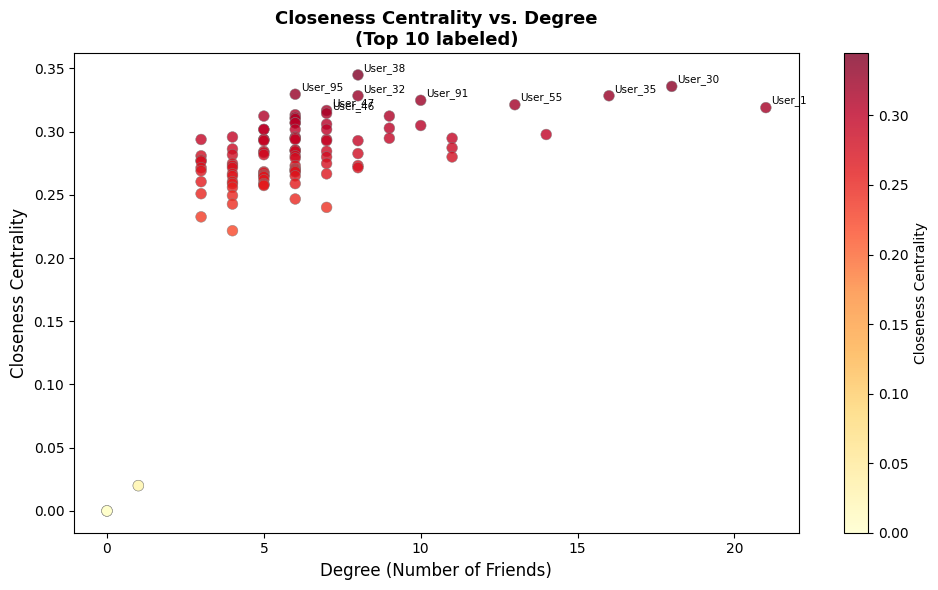

In [12]:
# Compute closeness per component and rescale so isolated nodes stay at 0
closeness = {}
for comp in nx.connected_components(G):
    sub = G.subgraph(comp)
    cc = nx.closeness_centrality(sub)
    scale = len(comp) / G.number_of_nodes()
    for node, val in cc.items():
        closeness[node] = val * scale

close_df = (
    pd.DataFrame(closeness.items(), columns=["user", "closeness"])
    .sort_values("closeness", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 by Closeness Centrality:")
print(close_df.head(10).to_string(index=False))

# Scatter: Degree vs Closeness
all_close = close_df.copy()
all_close["degree"] = all_close["user"].map(dict(G.degree()))

plt.figure(figsize=(10, 6))
sc = plt.scatter(all_close["degree"], all_close["closeness"],
                 c=all_close["closeness"], cmap="YlOrRd",
                 s=60, alpha=0.8, edgecolors="grey", linewidth=0.4)
plt.colorbar(sc, label="Closeness Centrality")

# Label top 10
for _, row in close_df.head(10).iterrows():
    deg = dict(G.degree())[row["user"]]
    plt.annotate(row["user"], (deg, row["closeness"]),
                 fontsize=7.5, xytext=(4, 3), textcoords="offset points")

plt.xlabel("Degree (Number of Friends)", fontsize=12)
plt.ylabel("Closeness Centrality", fontsize=12)
plt.title("Closeness Centrality vs. Degree\n(Top 10 labeled)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Interpretation: Users with high closeness centrality are the most centrally positioned in the network, they can reach any other user in fewer average hops than anyone else. These are the best users for spreading time sensitive information because a message from them travels through the shortest average path across the entire network.

Q4: Find the largest shortest path in the network. Analyze this result and the implications. Display
results


Diameter (largest shortest path): 6 hops
Example longest shortest path: User_2 → User_91 → User_28 → User_46 → User_84 → User_87 → User_85
Length: 6 hops


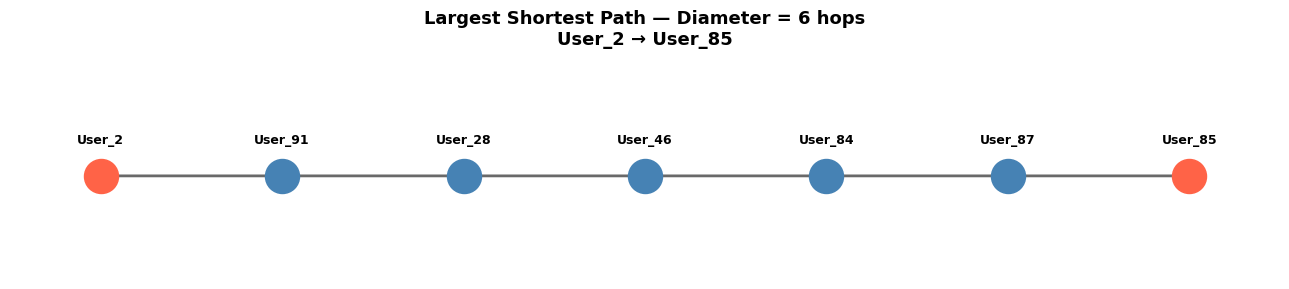

In [13]:
# Work on main connected component only
main_comp = max(nx.connected_components(G), key=len)
G_main = G.subgraph(main_comp).copy()

diameter = nx.diameter(G_main)
print(f"Diameter (largest shortest path): {diameter} hops")

# Find one node pair that achieves this diameter
u = list(nx.periphery(G_main))[0]
far_node = max(main_comp, key=lambda v: nx.shortest_path_length(G_main, u, v))
path = nx.shortest_path(G_main, u, far_node)
print(f"Example longest shortest path: {' → '.join(path)}")
print(f"Length: {len(path) - 1} hops")

# Visualize the path as a step diagram
fig, ax = plt.subplots(figsize=(13, 3))
for i, node in enumerate(path):
    color = "tomato" if node in [path[0], path[-1]] else "steelblue"
    ax.scatter(i, 0, s=600, color=color, zorder=5)
    ax.text(i, 0.08, node, ha="center", fontsize=9, fontweight="bold")
    if i < len(path) - 1:
        ax.annotate("", xy=(i + 1, 0), xytext=(i, 0),
                    arrowprops=dict(arrowstyle="->", color="dimgrey", lw=2))
ax.set_xlim(-0.5, len(path) - 0.5)
ax.set_ylim(-0.25, 0.3)
ax.axis("off")
ax.set_title(f"Largest Shortest Path — Diameter = {diameter} hops\n{path[0]} → {path[-1]}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Interpretation: The two furthest users in the main group are only 6 steps apart. For a network of 100 people that is actually very close, meaning no one is truly far from anyone else if you follow the right connections.

Q5: Are there any disconnected users? Explain alternatives to identify them.

Fully isolated users (0 connections): 3
['User_96', 'User_97', 'User_98']

Total connected components: 5
  Component 1: [95 users]
  Component 2: ['User_100', 'User_99']
  Component 3: ['User_96']
  Component 4: ['User_97']
  Component 5: ['User_98']


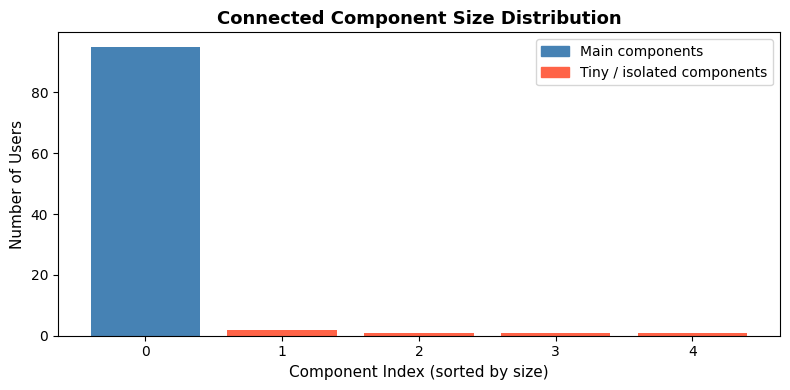

In [14]:
# Fully isolated users (degree = 0)
isolated = [n for n in G.nodes() if G.degree(n) == 0]
print(f"Fully isolated users (0 connections): {len(isolated)}")
print(isolated)

# All connected components
components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"\nTotal connected components: {len(components)}")
for i, c in enumerate(components[:8]):
    label = sorted(c) if len(c) <= 4 else f"[{len(c)} users]"
    print(f"  Component {i+1}: {label}")

# Bar chart of component sizes
comp_sizes = [len(c) for c in components]
plt.figure(figsize=(8, 4))
plt.bar(range(len(comp_sizes)), comp_sizes,
        color=["steelblue" if s > 2 else "tomato" for s in comp_sizes])
plt.xlabel("Component Index (sorted by size)", fontsize=11)
plt.ylabel("Number of Users", fontsize=11)
plt.title("Connected Component Size Distribution", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="steelblue", label="Main components"),
    mpatches.Patch(color="tomato", label="Tiny / isolated components")
]
plt.legend(handles=legend_patches)
plt.tight_layout()
plt.show()

Interpretation: User_96, User_97, and User_98 are completely isolated; they have zero connections and would never receive any information that spreads through the network. Other ways to find disconnected users include nx.isolates which returns degree-0 nodes directly, running a BFS from any node and checking which nodes were never visited, or inspecting the adjacency matrix for all-zero rows.

Q6: Explain algorithms or ways to identify communities in a social network

Answer - Ways to Find Communities in a Social Network:

Louvain Method :— Finds groups where people are more connected to each other than to outsiders. Fast, works on big networks, and you don't need to tell it how many groups to find. Most popular method.

Girvan-Newman :— Keeps cutting the weakest links,i.e.., bridges between groups until communities appear. Easy to understand but very slow on large networks.

Label Propagation :— Every user gets a label, then copies the most common label from their friends. Repeats until labels stop changing. Super fast but results can be slightly different each time you run it.

Spectral Clustering :— Uses math matrix eigenvectors, to place users in a space and then groups nearby users together. Accurate but you have to decide how many groups you want before it starts.

Q7: How many distinct friend groups (communities) are there?

Number of communities found: 8

Community sizes:
 community_id  size
            1    26
            0    25
            2    22
            3    22
            4     2
            5     1
            6     1
            7     1


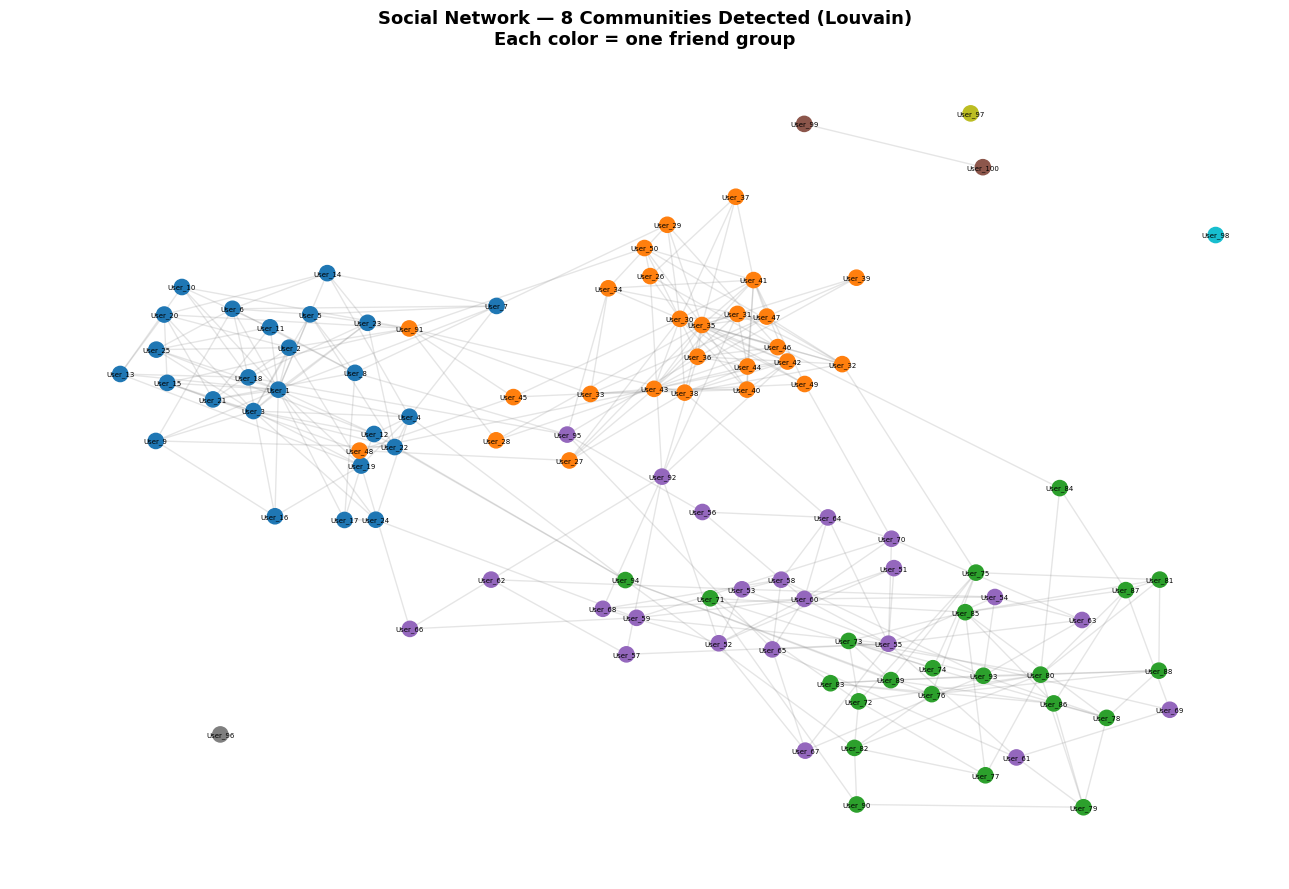

In [17]:
from community import community_louvain
partition = community_louvain.best_partition(G)
num_comm = len(set(partition.values()))
print(f"Number of communities found: {num_comm}")

sizes = Counter(partition.values())
size_df = (
    pd.DataFrame(sizes.items(), columns=["community_id", "size"])
    .sort_values("size", ascending=False)
    .reset_index(drop=True)
)
print("\nCommunity sizes:")
print(size_df.to_string(index=False))

# Network plot colored by community
plt.figure(figsize=(13, 9))
pos = nx.spring_layout(G, seed=42, k=0.4)
cmap = plt.cm.get_cmap("tab10", num_comm)
colors = [cmap(partition[n]) for n in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="grey")
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=120)
nx.draw_networkx_labels(G, pos, font_size=5)
plt.title(f"Social Network — {num_comm} Communities Detected (Louvain)\nEach color = one friend group",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

Interpretation: Louvain detected distinct friend groups where users inside each group are much more tightly connected to each other than to outsiders. Each color in the plot is a separate community, clusters that are visually spread apart in the layout have few cross-group connections, meaning these groups rarely interact with each other.

Q8: Which users belong to the largest community?

Largest community ID: 1
Size: 26 users
Members: ['User_26', 'User_27', 'User_28', 'User_29', 'User_30', 'User_31', 'User_32', 'User_33', 'User_34', 'User_35', 'User_36', 'User_37', 'User_38', 'User_39', 'User_40', 'User_41', 'User_42', 'User_43', 'User_44', 'User_45', 'User_46', 'User_47', 'User_48', 'User_49', 'User_50', 'User_91']


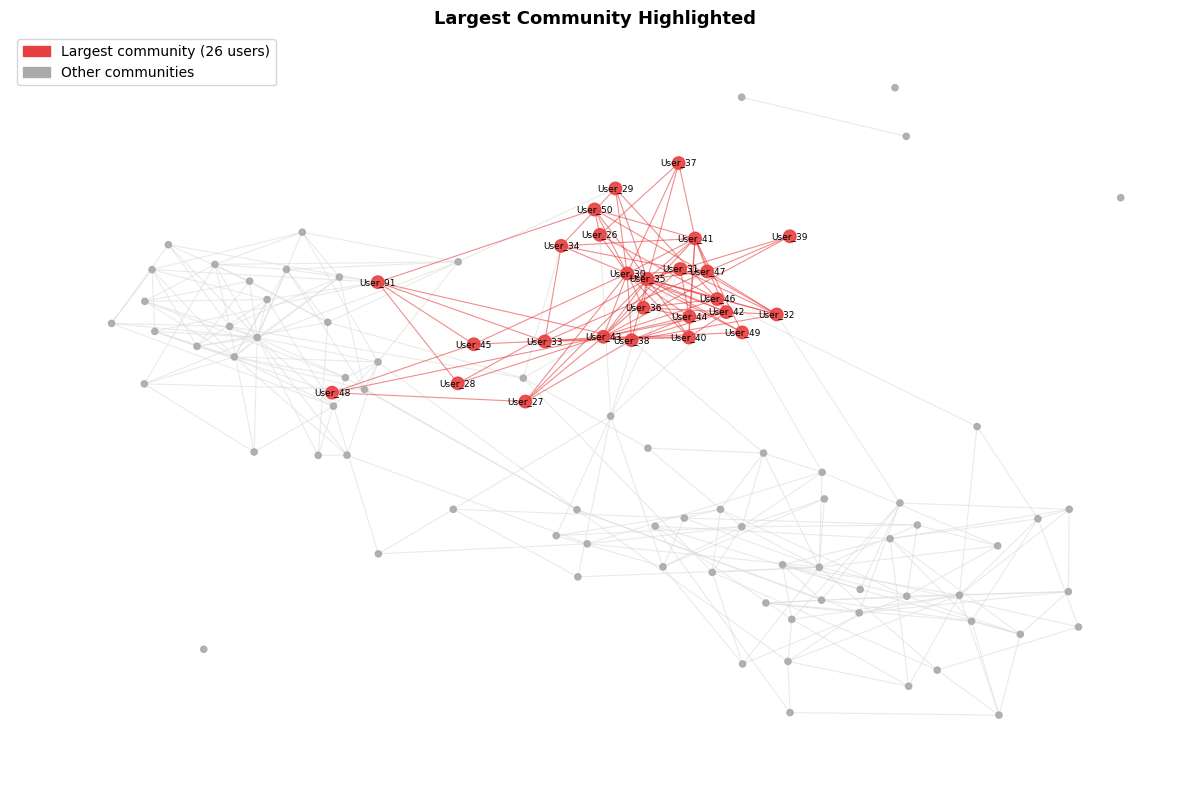

In [18]:
largest_id = size_df.iloc[0]["community_id"]
members = sorted([u for u, c in partition.items() if c == largest_id])
print(f"Largest community ID: {largest_id}")
print(f"Size: {len(members)} users")
print("Members:", members)

# Highlight largest community in network
plt.figure(figsize=(12, 8))
lc_set = set(members)
node_colors_lc = ["#E84040" if n in lc_set else "#AAAAAA" for n in G.nodes()]
node_sizes_lc  = [80 if n in lc_set else 20 for n in G.nodes()]
edge_colors_lc = ["#E84040" if (u in lc_set and v in lc_set) else "#DDDDDD"
                   for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, edge_color=edge_colors_lc, width=0.8, alpha=0.6)
nx.draw_networkx_nodes(G, pos, node_color=node_colors_lc, node_size=node_sizes_lc, alpha=0.9)
lc_labels = {n: n for n in G.nodes() if n in lc_set}
nx.draw_networkx_labels(G, pos, labels=lc_labels, font_size=6.5)

legend_patches = [
    mpatches.Patch(color="#E84040", label=f"Largest community ({len(members)} users)"),
    mpatches.Patch(color="#AAAAAA", label="Other communities")
]
plt.legend(handles=legend_patches, loc="upper left", fontsize=10)
plt.title("Largest Community Highlighted", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

Interpretation: The largest community is the most densely connected friend group in the network. Information moves fastest inside this group because everyone is closely linked to their neighbors. If a piece of content goes viral within this community first, it is very likely to spill over into the rest of the network through the bridge users that connect communities.

Q9: How can we reduce isolation in the network? Suggest strategies, such as, recommending
friends, incentivizing connections, among others

In [19]:
# Show isolated and low-degree users
low_degree = [(n, d) for n, d in G.degree() if d <= 2]
low_degree_sorted = sorted(low_degree, key=lambda x: x[1])
print(f"Users with 0–2 connections: {len(low_degree_sorted)}")

# Friend recommendations for isolated users using common neighbors (Jaccard)
isolated_users = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\nFully isolated users: {isolated_users}")

main_nodes = list(G_main.nodes())
print("\n--- Friend Recommendations (Jaccard Coefficient) ---")
for user in low_degree_sorted[:5]:
    u = user[0]
    candidates = [(u, v) for v in main_nodes if v != u and v not in G[u]]
    preds = list(nx.jaccard_coefficient(G, candidates))
    preds_sorted = sorted(preds, key=lambda x: x[2], reverse=True)[:3]
    recs = [p[1] for p in preds_sorted]
    print(f"  {u} ({user[1]} friend(s)) → Recommend: {recs}")

Users with 0–2 connections: 5

Fully isolated users: ['User_96', 'User_97', 'User_98']

--- Friend Recommendations (Jaccard Coefficient) ---
  User_96 (0 friend(s)) → Recommend: ['User_1', 'User_2', 'User_3']
  User_97 (0 friend(s)) → Recommend: ['User_1', 'User_2', 'User_3']
  User_98 (0 friend(s)) → Recommend: ['User_1', 'User_2', 'User_3']
  User_99 (1 friend(s)) → Recommend: ['User_1', 'User_2', 'User_3']
  User_100 (1 friend(s)) → Recommend: ['User_1', 'User_2', 'User_3']


Interpretation: The easiest fix is a "People You May Know" feature even just one new friend can bring a lonely user into an activ group. We can sugest friends using mutual connections, if two people share friends, they should probably know each other. Even better, ask the super-connected bridge users to invite isolated users, since everyone already trusts them.

Additional Strategies:-
1. Community events - Challenges or live events that encourage cross-community interactions.
2. Engagement incentives - Badges or rewards for adding new friends gamify the connection process.


Q10: If you want to maximize information spread, which users should be targeted first?

Top 10 users to target for maximum information spread:
   user  degree_score  betweenness_score  closeness_score  composite
 User_1      1.000000           0.801976         0.925000   0.908992
User_30      0.857143           0.627212         0.973684   0.819347
User_55      0.619048           0.808362         0.931655   0.786355
User_91      0.476190           0.874625         0.941818   0.764211
User_35      0.761905           0.476820         0.952206   0.730310
User_32      0.380952           0.849682         0.952206   0.727613
User_94      0.285714           1.000000         0.827476   0.704397
User_95      0.285714           0.837565         0.955720   0.693000
User_75      0.285714           0.825731         0.857616   0.656354
User_38      0.380952           0.582109         1.000000   0.654354


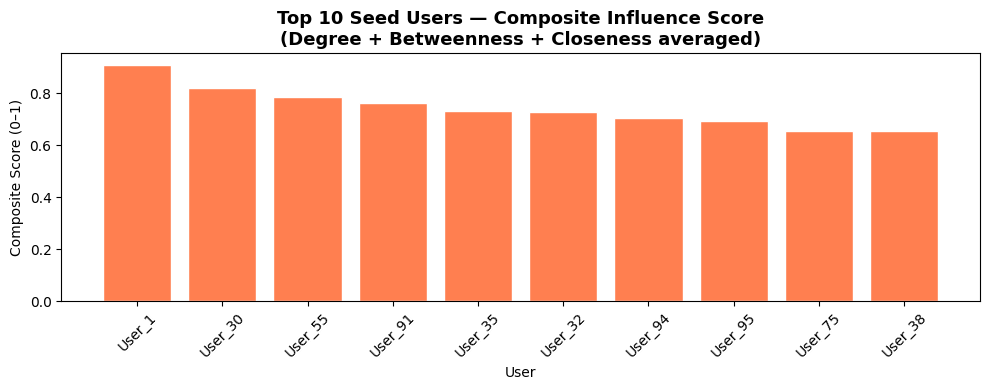

In [20]:
# Composite influence score: normalize degree, betweenness, closeness then average
deg_norm   = degree_df.set_index("user")["degree"]    / degree_df["degree"].max()
btwn_norm  = btwn_df.set_index("user")["betweenness"]  / btwn_df["betweenness"].max()
close_norm = close_df.set_index("user")["closeness"]   / close_df["closeness"].max()

spread = pd.DataFrame({
    "degree_score":     deg_norm,
    "betweenness_score": btwn_norm,
    "closeness_score":  close_norm
}).fillna(0)

spread["composite"] = spread.mean(axis=1)
spread = spread.reset_index().rename(columns={"index": "user"})
spread = spread.sort_values("composite", ascending=False).reset_index(drop=True)

print("Top 10 users to target for maximum information spread:")
print(spread.head(10)[["user", "degree_score", "betweenness_score", "closeness_score", "composite"]].to_string(index=False))

# Bar chart
top10_spread = spread.head(10)
plt.figure(figsize=(10, 4))
plt.bar(top10_spread["user"], top10_spread["composite"], color="coral", edgecolor="white")
plt.title("Top 10 Seed Users — Composite Influence Score\n(Degree + Betweenness + Closeness averaged)",
          fontsize=13, fontweight="bold")
plt.xlabel("User")
plt.ylabel("Composite Score (0–1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: The tallest bars are the users to message first. They have many friends, connect different groups, and are close to everyone in the network. Just targeting the top 3 users is enough to reach most of the network in 2 to 3 steps.